In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
print("Pandas版本：",pd.__version__); print("NumPy版本：",np.__version__)

Pandas版本： 2.3.3
NumPy版本： 2.0.2


## 1. Pandas 文本清洗、分词和词频统计

In [40]:
data={"text":["Hello World!","NLP is amazing","Python 3.8"],"label":[1,0,1]}
df=pd.DataFrame(data); print(df)

             text  label
0    Hello World!      1
1  NLP is amazing      0
2      Python 3.8      1


In [41]:
df["clean_text"]=df["text"].str.lower().str.replace(r"[^\w\s]","",regex=True); df["tokens"]=df["clean_text"].str.split(); word_counts=df["tokens"].explode().value_counts()
print(df); print("\n词频：\n",word_counts)

             text  label      clean_text              tokens
0    Hello World!      1     hello world      [hello, world]
1  NLP is amazing      0  nlp is amazing  [nlp, is, amazing]
2      Python 3.8      1       python 38        [python, 38]

词频：
 tokens
hello      1
world      1
nlp        1
is         1
amazing    1
python     1
38         1
Name: count, dtype: int64


## 2. NumPy 词向量和余弦相似度

In [42]:
word_vectors=np.array([[0.1,0.2,0.3,0.4,0.5],[0.6,0.7,0.8,0.9,1.0],[1.1,1.2,1.3,1.4,1.5]])
def cosine_similarity(a,b):
    denominator=np.linalg.norm(a)*np.linalg.norm(b)
    return float(np.dot(a,b)/denominator) if denominator!=0 else 0.0

print("词向量矩阵形状：",word_vectors.shape); print("前两个词相似度：",cosine_similarity(word_vectors[0],word_vectors[1]))

词向量矩阵形状： (3, 5)
前两个词相似度： 0.9649505047327672


In [43]:
normalized=word_vectors/np.linalg.norm(word_vectors,axis=1,keepdims=True); similarity_matrix=normalized@normalized.T
print("全部词向量相似度矩阵：\n",similarity_matrix)

全部词向量相似度矩阵：
 [[1.         0.9649505  0.9453431 ]
 [0.9649505  1.         0.99778241]
 [0.9453431  0.99778241 1.        ]]


## 3. Scikit-learn TF-IDF

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus=["This is the first document.","This document is the second document.","And this is the third one."]
vectorizer=TfidfVectorizer(); X=vectorizer.fit_transform(corpus)
print("特征矩阵形状：",X.shape); print("特征词汇：",vectorizer.get_feature_names_out()); print("稠密矩阵：\n",X.toarray())

特征矩阵形状： (3, 9)
特征词汇： ['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']
稠密矩阵：
 [[0.         0.46941728 0.61722732 0.3645444  0.         0.
  0.3645444  0.         0.3645444 ]
 [0.         0.7284449  0.         0.28285122 0.         0.47890875
  0.28285122 0.         0.28285122]
 [0.49711994 0.         0.         0.29360705 0.49711994 0.
  0.29360705 0.49711994 0.29360705]]


## 4. 完整机器学习 Pipeline

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

texts=["good movie","bad film","great story","terrible acting","excellent plot","awful ending"]*40
labels=[1,0,1,0,1,0]*40
X_train,X_test,y_train,y_test=train_test_split(texts,labels,test_size=0.25,random_state=42,stratify=labels)
nlp_pipeline=Pipeline([("tfidf",TfidfVectorizer(max_features=1000)),("clf",RandomForestClassifier(n_estimators=100,random_state=42))])
nlp_pipeline.fit(X_train,y_train); predictions=nlp_pipeline.predict(X_test)
print("测试准确率：",nlp_pipeline.score(X_test,y_test)); print(classification_report(y_test,predictions))

测试准确率： 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        30

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



## 5. Matplotlib 词频柱状图

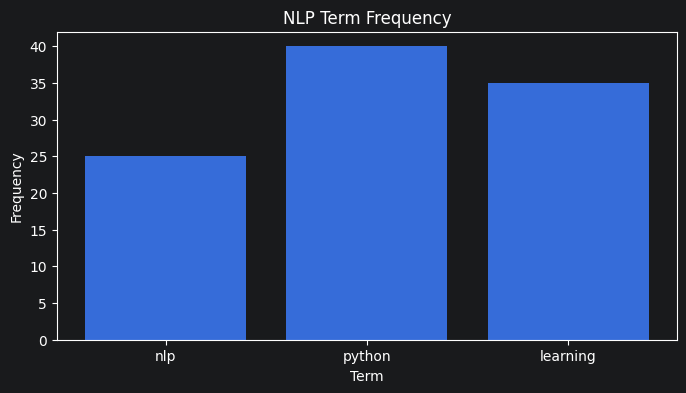

In [46]:
words=["nlp","python","learning"]; frequencies=[25,40,35]
plt.figure(figsize=(8,4)); plt.bar(words,frequencies); plt.title("NLP Term Frequency"); plt.xlabel("Term"); plt.ylabel("Frequency"); plt.show()

## 6. Seaborn TF-IDF 热力图

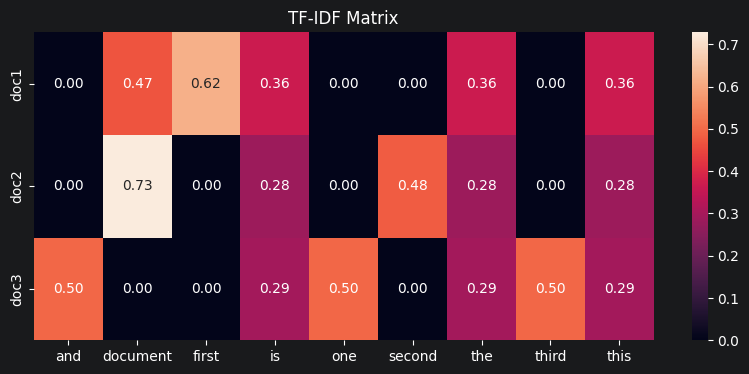

In [47]:
try:
    import seaborn as sns
    seaborn_ready=True
except ImportError:
    seaborn_ready=False
if seaborn_ready:
    plt.figure(figsize=(10,4)); sns.heatmap(X.toarray(),annot=True,fmt=".2f",xticklabels=vectorizer.get_feature_names_out(),yticklabels=["doc1","doc2","doc3"]); plt.title("TF-IDF Matrix"); plt.show()
else: print("Seaborn未安装，跳过。")

## 7. WordCloud

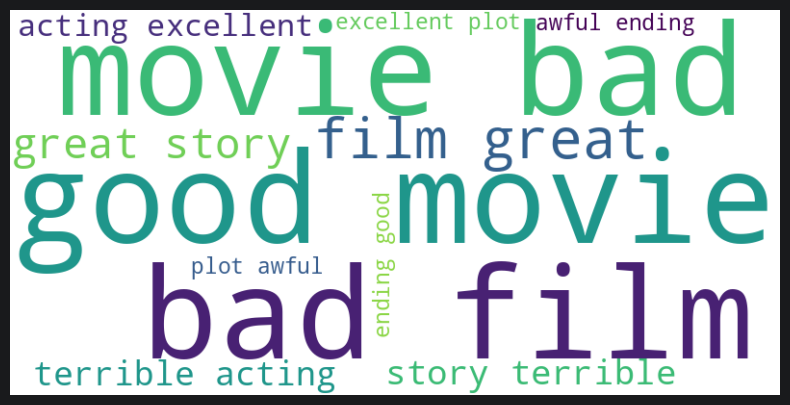

In [48]:
try:
    from wordcloud import WordCloud
    wordcloud_ready=True
except ImportError:
    wordcloud_ready=False
if wordcloud_ready:
    wordcloud=WordCloud(width=800,height=400,background_color="white").generate(" ".join(texts)); plt.figure(figsize=(10,5)); plt.imshow(wordcloud,interpolation="bilinear"); plt.axis("off"); plt.show()
else: print("WordCloud未安装，跳过。")

## 8. Plotly 三维词向量

In [49]:
import os
import numpy as np
import pandas as pd
import plotly.express as px

embeddings=np.array([[0.1,0.2,0.3],[0.5,0.4,0.2],[0.9,0.1,0.7],[0.2,0.8,0.6]])
embedding_words=["自然","语言","处理","模型"]

plot_df=pd.DataFrame(embeddings,columns=["x","y","z"])
plot_df["word"]=embedding_words

fig=px.scatter_3d(plot_df,x="x",y="y",z="z",text="word",title="三维词向量")

html_path=r"D:\11\NLP\data\三维词向量.html"
fig.write_html(html_path,include_plotlyjs=True,auto_open=True)

print("图表保存成功：",html_path)
print("文件是否存在：",os.path.isfile(html_path))

图表保存成功： D:\11\NLP\data\三维词向量.html
文件是否存在： True


Z## 9. 完整情感分析流程：使用内置 DataFrame，不依赖 reviews.csv

In [50]:
reviews=pd.DataFrame({"text":["This movie is wonderful","I love this product","The service was excellent","This film is terrible","I hate the interface","The quality is awful","A great experience","A very bad purchase"],"sentiment":[1,1,1,0,0,0,1,0]})
reviews["clean_text"]=reviews["text"].str.lower().str.replace(r"[^\w\s]","",regex=True)
print(reviews)

                        text  sentiment                 clean_text
0    This movie is wonderful          1    this movie is wonderful
1        I love this product          1        i love this product
2  The service was excellent          1  the service was excellent
3      This film is terrible          0      this film is terrible
4       I hate the interface          0       i hate the interface
5       The quality is awful          0       the quality is awful
6         A great experience          1         a great experience
7        A very bad purchase          0        a very bad purchase


In [51]:
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix,accuracy_score

sentiment_vectorizer=TfidfVectorizer(max_features=5000); sentiment_X=sentiment_vectorizer.fit_transform(reviews["clean_text"]); sentiment_y=reviews["sentiment"]
sentiment_model=LinearSVC(); sentiment_model.fit(sentiment_X,sentiment_y); sentiment_pred=sentiment_model.predict(sentiment_X); cm=confusion_matrix(sentiment_y,sentiment_pred)
print("训练集准确率：",accuracy_score(sentiment_y,sentiment_pred)); print("混淆矩阵：\n",cm)

训练集准确率： 1.0
混淆矩阵：
 [[4 0]
 [0 4]]


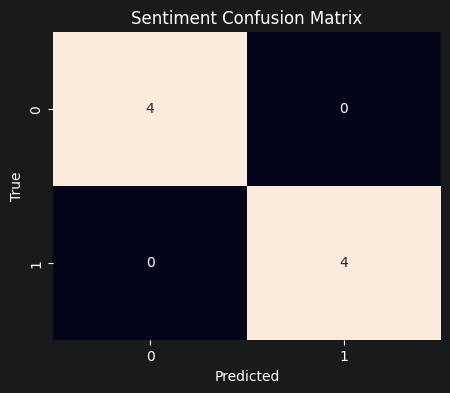

In [52]:
if seaborn_ready:
    plt.figure(figsize=(5,4)); sns.heatmap(cm,annot=True,fmt="d",cbar=False); plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Sentiment Confusion Matrix"); plt.show()
else:
    plt.figure(figsize=(5,4)); plt.imshow(cm); plt.colorbar(); plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Sentiment Confusion Matrix"); plt.show()

## 10. 保存本地数据和模型

In [53]:
import joblib

data_path=r"D:\11\NLP\data\reviews_toy.csv"; model_path=r"D:\11\NLP\data\sentiment_pipeline_local.joblib"
os.makedirs(os.path.dirname(data_path),exist_ok=True); reviews.to_csv(data_path,index=False,encoding="utf-8-sig")
sentiment_pipeline=Pipeline([("tfidf",TfidfVectorizer(max_features=5000)),("clf",LinearSVC())]); sentiment_pipeline.fit(reviews["clean_text"],reviews["sentiment"]); joblib.dump(sentiment_pipeline,model_path)
print("数据已保存：",data_path); print("模型已保存：",model_path)

数据已保存： D:\11\NLP\data\reviews_toy.csv
模型已保存： D:\11\NLP\data\sentiment_pipeline_local.joblib
